# Neural Tangent Kernel: Convergence and Generalization in Neural Networks
Jacot, Arthur, Franck Gabriel, and Clément Hongler. "Neural tangent kernel: convergence and generalization in neural networks." Proceedings of the 32nd International Conference on Neural Information Processing Systems. 2018. https://papers.nips.cc/paper/2018/file/5a4be1fa34e62bb8a6ec6b91d2462f5a-Paper.pdf

This notebook was created by:
- Kimia Hamidieh
- Nathan Ng
-  Haoran Zhang

as part of a presentation for the course CSC2541 Winter 2021 (Neural Network Training Dynamics) at the University of Toronto.

In [1]:
import jax.numpy as np
from jax.nn import relu, sigmoid, log_softmax, softmax
from jax import grad, vmap, random, jit, value_and_grad, jvp, jacfwd
import jax
import seaborn as sns

import itertools
from matplotlib import rc
rc('animation', html='jshtml')
from math import *
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import matplotlib.animation as animation

from torchvision.datasets import MNIST

# set sns styles
sns.set(rc={'figure.figsize':(8, 8)})
sns.set_style('white')

skey = random.PRNGKey(1337)

In [2]:
# load mnist, randomly select 1024 samples
mnist_dataset = MNIST('/tmp/mnist/', download=True)
selected_inds = random.choice(random.PRNGKey(42), len(mnist_dataset.data), shape = (1024, ), replace = False)
mnist_X = mnist_dataset.data.numpy()[selected_inds].reshape(1024, -1)/255
mnist_Y = mnist_dataset.targets.numpy()[selected_inds]
mnist_d = 28*28

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.22MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 165kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.59MB/s]


In [3]:
@jit
def mse(w, b, x, targets, *args, **kwargs):
  preds = nn(x, w, b, *args, **kwargs)
  return np.mean((preds - targets)**2)

@jit
def cross_entropy(w, b, x, targets, *args, **kwargs):
  logprobs = nn(x, w, b, *args, **kwargs)
  return -np.mean(np.take_along_axis(logprobs, np.expand_dims(targets, axis=1), axis=1))

# Changes in Weights during Training

Typically when we train neural networks, we perform gradient descent in the weight space, updating them based on the gradient of the loss. Let's consider how the weights in a neural network change over time as we increase the width of the network.

We consider neural networks consisting of 1 hidden layer with $m$ neurons on MNIST with the cross-entropy loss, defined by the following equations:
\begin{align}
a^{(0)} &= x \\
\tilde{a}^{(1)} &= \frac{1}{\sqrt{m}} W^{(1)} a^{(0)} + \beta b^{(0)}\\
a^{(1)} &= ReLU(\tilde{a}^{(1)}) \\
\tilde{a}^{(2)} &= \frac{1}{\sqrt{10}} W^{(2)} a^{(1)} + \beta b^{(1)}\\
a^{(2)} &=  Softmax(\tilde{a}^{(2)}) \\
\end{align}

We initialize $W^{(1)}_{ij} \sim \mathcal{N}(0, 1)$, and $b^{(i)} = 0$. \\
We vary $m \in \{10, 100, 1000\}$, and train 10 networks with different initializations for each value of $m$.

In [4]:
# nn forward function
def nn(xs, w, b, hidden_activation = relu, final_activation = log_softmax, beta=0.1):
  n_layers = len(w)
  for i in range(n_layers - 1):
    xs = np.dot(xs, w[i])/np.sqrt(w[i].shape[1]) + b[i] * beta
    xs = hidden_activation(xs)
  xs = np.dot(xs, w[-1])/np.sqrt(w[-1].shape[1]) + b[-1] * beta
  return final_activation(xs) if final_activation else xs

In [5]:
def generate_weights(d, skey, n_units = [50, 10]):
  ws = []
  bs = []
  n_units = [d] + n_units
  for i in range(1, len(n_units)):
    skey, subkey = random.split(skey)
    ws.append(random.normal(skey, (n_units[i-1], n_units[i])))
  for i in range(1, len(n_units)):
    skey, subkey = random.split(skey)
    bs.append(np.zeros((n_units[i],)))
  return ws, bs, skey


def grad_step(x, targets, loss_func, ws, bs, *args, **kwargs):
  return value_and_grad(loss_func, argnums = [0,1])(ws, bs, x, targets, *args, **kwargs)

We train the network for 100 epochs and plot as a function of time $t$:

 $\frac{||W^{(1)}(t) - W^{(1)}(0)||_F}{||W^{(1)}(0)||_F}$ - the distance that the network weights have moved from their initial values.

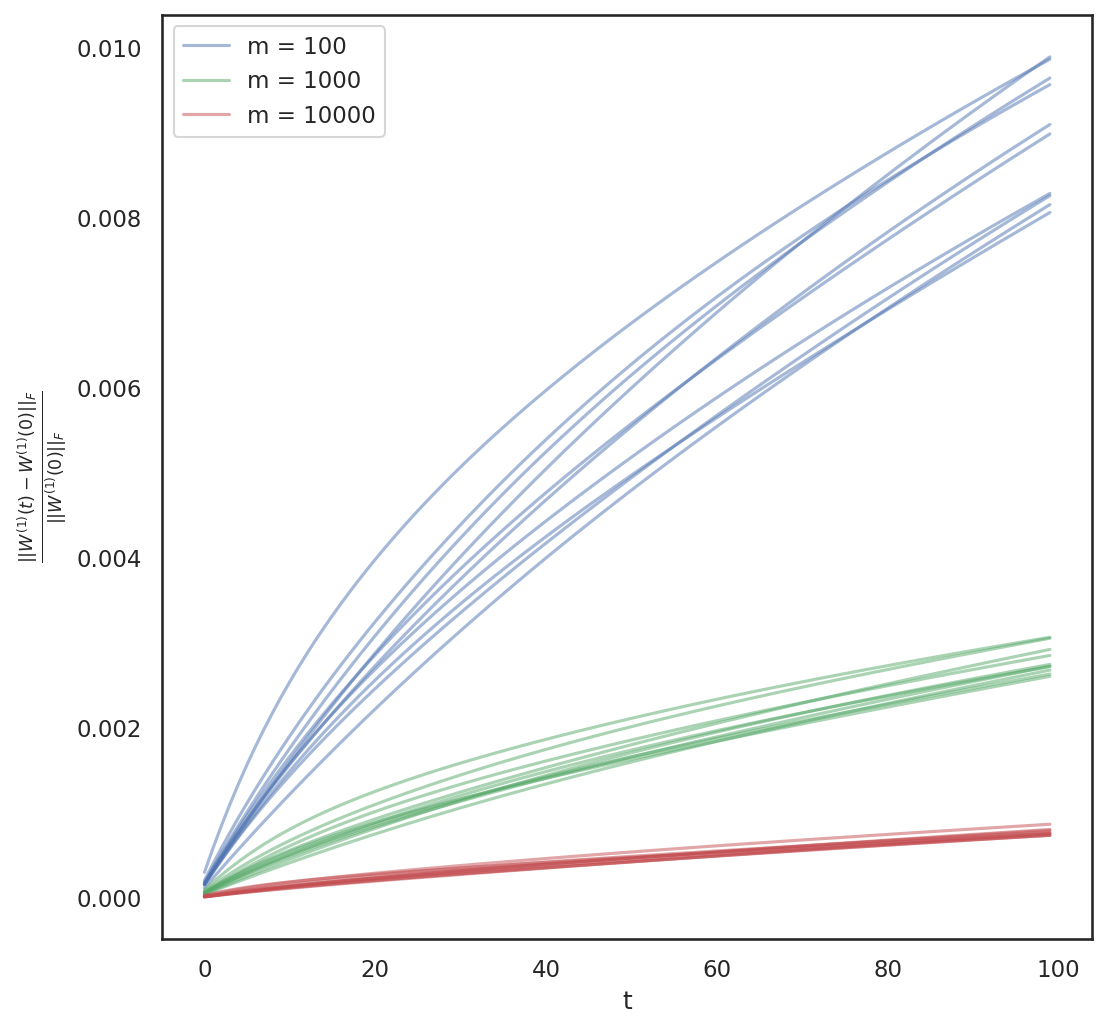

In [6]:
lr = 0.1
n_epochs = 100
reps = 10
ms = [100, 1000, 10000]
colors = ['b','g','r', 'y']

temp = {i: [] for i in ms}

plt.figure(dpi = 150)
for c, m in enumerate(ms):
  for i in range(reps):
    w, b, skey = generate_weights(mnist_d, skey, n_units = [m, 10])
    w_init = w.copy()
    init_norm = np.linalg.norm(w_init[0])
    distances = []

    for epoch in range(n_epochs):
      loss, grads = grad_step(mnist_X, mnist_Y, cross_entropy, w, b)
      w = [wi - lr * dw for wi, dw in zip(w, grads[0])]
      b = [bi - lr * db for bi, db in zip(b, grads[1])]
      distances.append(np.linalg.norm(w[0] - w_init[0]) / init_norm)

    plt.plot(np.arange(n_epochs), distances, color = colors[c], alpha = 0.5, label = f'm = {m}' if i == 0 else None)
    plt.xlabel('t')
    plt.ylabel(r'$\frac{||W^{(1)}(t) - W^{(1)}(0)||_F}{||W^{(1)}(0)||_F}$')

    temp[m].append(distances)

plt.legend()
plt.show()

Interestingly, as the network width grows, the relative magnitude of the total gradient update approaches 0, meaning the network barely changes over the course of training! This implies that we can perform a Taylor expansion of our output function $f(w, x)$ around the initial weights $w_0$.

\begin{align}
f(w, x) \approx f(w_0, x) + \nabla_wf(w_0, x)^\intercal(w - w_0)
\end{align}

Note that this approximation is linear in $w$. This motivates the view of $\nabla_wf(w_0, x)$ as a non-linear transformation of $x$.

If we define $\phi(x) = \nabla_wf(w_0, x)$, we can define the kernel $k(x_i, x_j) = <\phi(x_i), \phi(x_j)>$. This is exactly the NTK evaluated at model initialization.

<!-- Consider the squared loss $\mathcal{L}(w) = \frac{1}{2}(f(w, x_i) - y_i)^2$. We can write the gradient descent update as

\begin{align}
w(t+1) &= w(t) - \eta \sum_{i=1}^N  (f(w(t), x_i) - y_i) \cdot \nabla_w f(w(t), x_i)
\end{align}


We see from the NTK paper that for large $m$, ... Gradient descent is then equivalent to doing kernel regression on the NTK. -->



# The Unit Circle Dataset
For the remainder of the notebook, we will experiment with the unit circle dataset outlined in Section 6.1 of the paper. It is a simple regression task with two features.

The data generation process is as follows:
\begin{gathered}
\gamma \sim \mathcal{N}(0, 1), \text{  or  } \gamma \sim \text{Uniform}(-\pi, \pi) \\
(x_1, x_2) = (cos(\gamma), sin(\gamma)) \\
y = x_1 x_2
\end{gathered}


In [7]:
def unit_circle_data(skey, N = 512, linspace = False):
  if linspace:
    gammas = np.linspace(-np.pi, np.pi, num = N)
  else:
    skey, subkey = random.split(skey)
    gammas = random.normal(skey, shape = (N,))
  X = np.vstack((np.cos(gammas), np.sin(gammas))).T
  Y = X[:, 0] * X[:, 1]
  return gammas, X, Y, skey

<>:5: SyntaxWarning: invalid escape sequence '\g'
<>:5: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipython-input-623/1758133399.py:5: SyntaxWarning: invalid escape sequence '\g'
  ax.set_xlabel('$\gamma$')


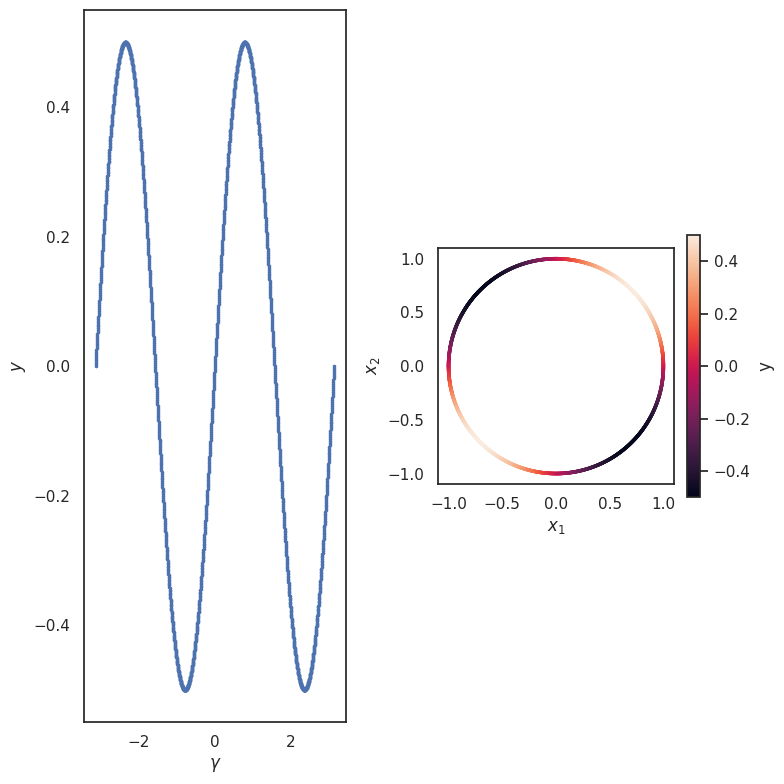

In [8]:
# visualize the unit circle dataset
gammas_plot, X_plot, Y_plot, skey = unit_circle_data(skey, 2048, linspace = True)
fig, axs = plt.subplots(ncols = 2, dpi = 100)
ax = axs[0]
ax.set_xlabel('$\gamma$')
ax.set_ylabel('$y$')
ax.scatter(x = gammas_plot, y = Y_plot, marker = '.', s = 10)

ax = axs[1]
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_aspect('equal', adjustable='box')
sc = ax.scatter(x = X_plot[:, 0], y = X_plot[:, 1], c = Y_plot, marker = '.', s = 10)
cb = plt.colorbar(sc, fraction=0.05)
cb.set_label('y')

plt.tight_layout()
plt.show()

# Changes in Function Space during Training

In order to find the kernel, we consider again the neural network above. Since we would like to find the kernel induced by gradient descent on our neural network, we now consider the shift in *function* space instead of *weight* space. We sample 10 random initializations of a 2 layer network and show the resulting functions below.

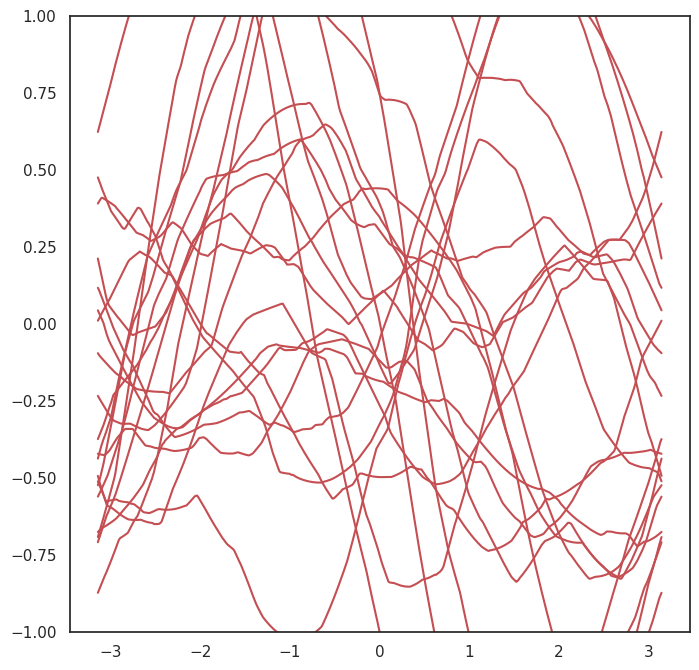

In [9]:
gammas_query, X_query, Y_query, skey = unit_circle_data(skey, 513, linspace = True) # (1,0) occurs at index 256

w_list = []
b_list = []
for i in range(20):
  w, b, skey = generate_weights(2, skey, n_units = [50, 1])
  w_list.append(w)
  b_list.append(b)

for w, b in zip(w_list, b_list):
  ys = nn(X_query, w, b, final_activation=None)
  plt.plot(gammas_query, ys, color='r')

plt.ylim(-1, 1)
#lt.xlim(-10, 10)
plt.show()

Let us consider one of these functions in particular.

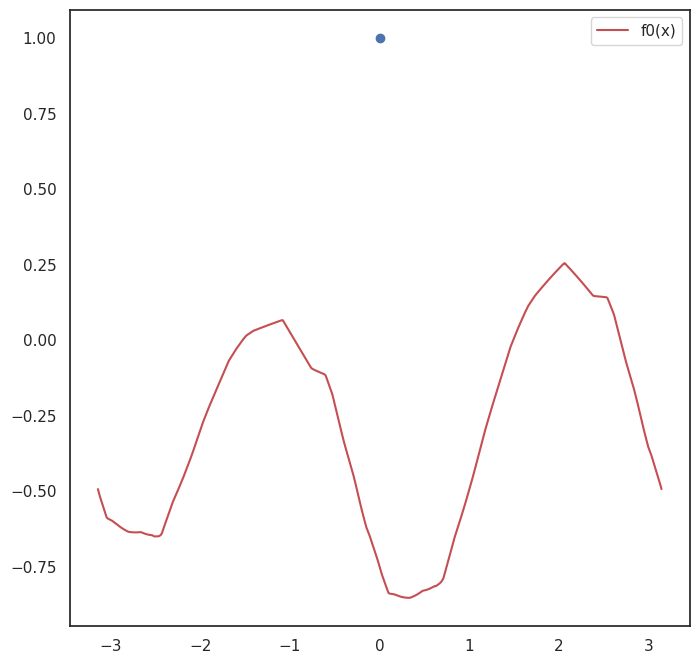

In [10]:
ys = nn(X_query, w_list[0], b_list[0], final_activation=None)
plt.plot(gammas_query, ys, color='r', label="f0(x)")
plt.plot(gammas_query[256], 1, 'bo')
#plt.ylim(-2, 2)
plt.legend()
plt.show()

What happens to this function when we perform gradient descent at the point shown in the plot above? We can visualize the change in function space by manually calculating the new weights and plotting the new function. Our original function $f^{(0)}(x)$ is shown in dotted red, and our new function $f^{(1)}(x)$ is shown in blue.

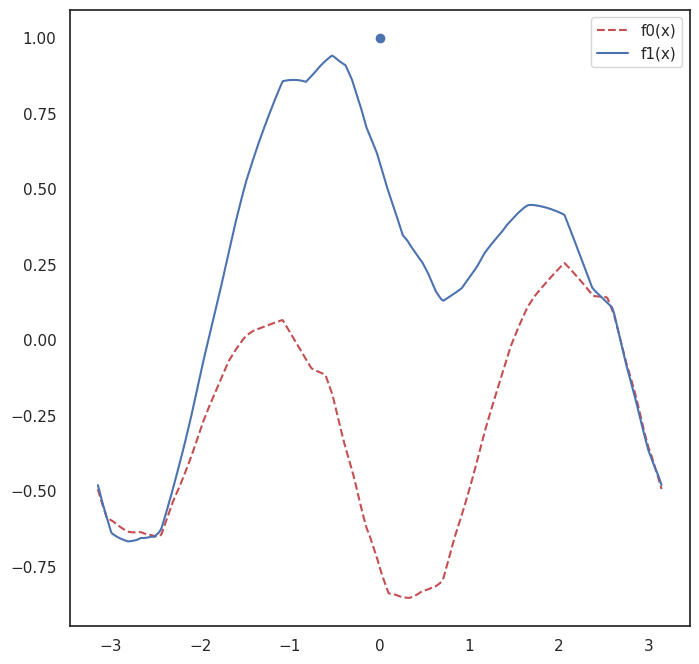

In [11]:
lr=0.4
ys = nn(X_query, w_list[0], b_list[0], final_activation=None)
plt.plot(gammas_query, ys, 'r--', label="f0(x)")

loss, grads = grad_step(X_query[256], np.asarray([1]), mse, w_list[0], b_list[0], final_activation=None)
plt.plot(gammas_query[256], 1, 'bo')
w = [wi - lr * dw for wi, dw in zip(w_list[0], grads[0])]
b = [bi - lr * db for bi, db in zip(b_list[0], grads[1])]

new_ys = nn(X_query, w, b, final_activation=None)
plt.plot(gammas_query, new_ys, 'b-', label="f1(x)")
#plt.ylim(-2, 2)
plt.legend()
plt.show()

The kernel is a bit hard to visualize here, so let's explicitply plot $K(x) = f^{(1)}(x) - f^{(0)}(x)$

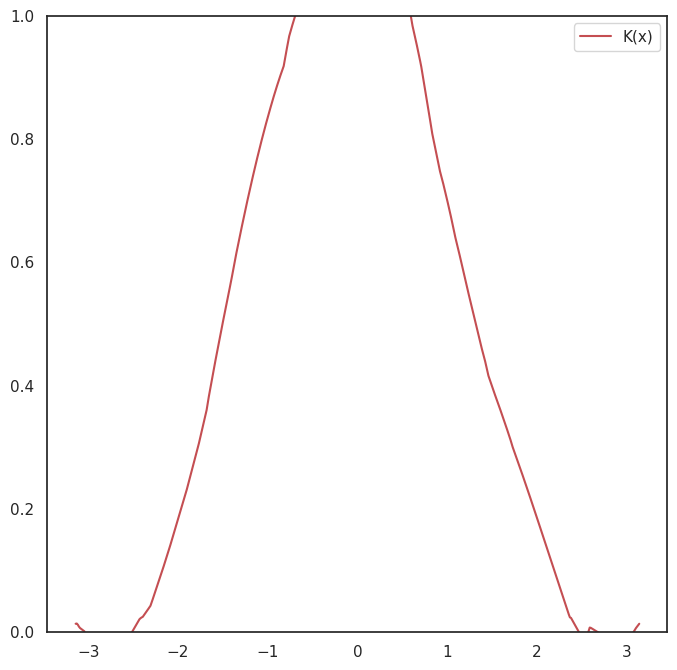

In [12]:
plt.plot(gammas_query, new_ys - ys, 'r-', label="K(x)")
plt.ylim(0, 1)
plt.legend()
plt.show()

Now let's repeat the process for the rest of the networks

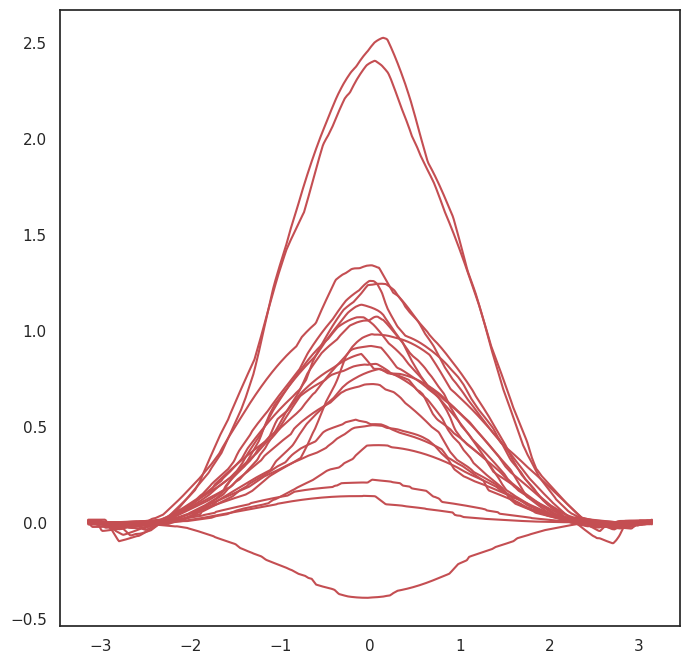

In [13]:
lr = 0.4

ys_list = []
newys_list = []

for w, b in zip(w_list, b_list):

  ys = nn(X_query, w, b, final_activation=None)
  ys_list.append(ys)

  loss, grads = grad_step(X_query[256], np.asarray([1]), mse, w, b, final_activation=None)
  w = [wi - lr * dw for wi, dw in zip(w, grads[0])]
  b = [bi - lr * db for bi, db in zip(b, grads[1])]

  ys = nn(X_query, w, b, final_activation=None)
  newys_list.append(ys)

for ys, new_ys in zip(ys_list, newys_list):
  plt.plot(gammas_query, new_ys - ys, 'r')

plt.show()

It seems like the gradient kernels are quite similar, even though the network initializations vary widely! In the limiting case as our network width grows to infinity, we can see that the kernels for our various networks converge to the exact same map.



In [ ]:
fig = plt.figure(figsize=(8,8))
ax = plt.axes()

def frame(n, skey):
  ax.clear()
  lr = 0.5 * 100.0/n

  w_list = []
  b_list = []
  for i in range(10):
    w, b, skey = generate_weights(2, skey, n_units = [n, 1])
    w_list.append(w)
    b_list.append(b)

  ys_list = []
  newys_list = []

  for w, b in zip(w_list, b_list):

    ys = nn(X_query, w, b, final_activation=None)
    ys_list.append(ys)

    loss, grads = grad_step(X_query[256], np.asarray([1]), mse, w, b, final_activation=None)
    w = [wi - lr * dw for wi, dw in zip(w, grads[0])]
    b = [bi - lr * db for bi, db in zip(b, grads[1])]

    ys = nn(X_query, w, b, final_activation=None)
    newys_list.append(ys)

  for ys, new_ys in zip(ys_list, newys_list):
    ax.plot(gammas_query, new_ys - ys, 'r')
  plt.ylim(0, 1.0)
  return ax

anim = animation.FuncAnimation(fig, frame, frames=[int(val) for val in np.logspace(7, 17, num=50, base = 2)], blit=False, repeat=True, fargs=[skey])

anim

# Neural Tangent Kernel

The limiting kernel shown above is called the neural tangent kernel (NTK).
The NTK is defined as $k(x_i, x_j) = \langle\nabla_W f(w, x_i), \nabla_W f(w, x_j)\rangle$. Let's define a function that returns the $N \times N$ Gram matrix for finite $m$ by directly computing the gradient.

In [ ]:
def NTK(w, b, x, layer_to_take = -1, *args, **kwargs):
  grad_mat = np.zeros((len(x), w[layer_to_take].size)) # the N x m matrix ∇w_f(w(t),X)
  forward_func = jit(lambda w, xi: nn(xi, w, b, *args, **kwargs)[0, 0]) # first output of NN
  for i in range(x.shape[0]):
    grad_mat = jax.ops.index_update(grad_mat, i, grad(forward_func, argnums = 0)(w, x[None, i])[layer_to_take].flatten())
  return grad_mat @ grad_mat.T

Following Figure 1 of the paper, we train neural networks of varying widths $m \in \{500, 10000\}$ for different epochs $t \in \{0, 200\}$. We plot the values of $k(x_i, x_j)$, fixing $x_i = (1, 0) = (cos(0), sin(0))$. This corresponds to a specific row in the Gram matrix.

In [ ]:
_, X_train, Y_train, skey = unit_circle_data(skey, 512)
gammas_query, X_query, Y_query, skey = unit_circle_data(skey, 513, linspace = True) # (1,0) occurs at index 256

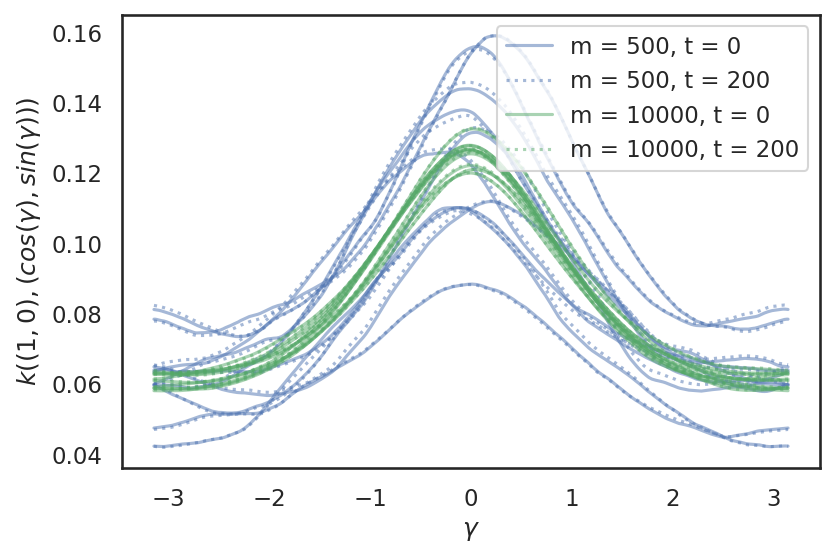

In [ ]:
ms = [500, 10000]
ts = [0, 200]
reps = 10
colors = ['b', 'g', 'r', 'y']
linestyles = ['solid','dotted']
lr = 0.01

plt.figure(dpi = 150)

for c, m in enumerate(ms):
  for i in range(reps):
    w, b, skey = generate_weights(2, skey, n_units = [m, m, m, 1])
    for t in range(max(ts) + 1):
      if t in ts:
        ntk = NTK(w, b, X_query, final_activation = None)
        plt.plot(gammas_query, ntk[256, :], c = colors[c], linestyle = linestyles[ts.index(t)],
                 label = f'm = {m}, t = {t}' if i == 0 else None, alpha = 0.5)

      loss, grads = grad_step(X_train, np.expand_dims(Y_train, axis = -1), mse, w, b, final_activation = None)
      w = [wi - lr * dw for wi, dw in zip(w, grads[0])]
      b = [bi - lr * db for bi, db in zip(b, grads[1])]


plt.xlabel('$\gamma$')
plt.ylabel('$k((1,0), (cos(\gamma), sin (\gamma)))$')
plt.legend()
plt.show()

We see that the kernel converges to a fixed limit as $m \rightarrow \infty$.

Following Figure 2 of the paper, we train neural networks on 4 arbitrarily chosen data points for 1000 steps, varying widths $m \in \{50, 1000\}$. For the infinite-width case, we use the `neural-tangents` library to obtain the infinite-width NTK.

In [ ]:
!pip install -q git+https://www.github.com/google/neural-tangents
from neural_tangents import stax
import neural_tangents as nt

In [ ]:
init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(1), stax.Relu(),
    stax.Dense(1), stax.Relu(),
    stax.Dense(1), stax.Relu(), # width doesn't matter since we're computing infinite width NTK
    stax.Dense(1)
)

In [ ]:
ms = [50, 1000]
reps = 5
points = np.array([-2.0, -1.0, 1.0, 2.0])
colors = ['g', 'r', 'b']
lr = 0.1

X_train_s = np.vstack((np.cos(points), np.sin(points))).T
Y_train_s = np.expand_dims(X_train_s[:, 0] * X_train_s[:, 1], axis = -1)

predict_fn = nt.predict.gradient_descent_mse_ensemble(kernel_fn, X_train_s,
                                                      Y_train_s)
ntk_mean, ntk_covariance = predict_fn(x_test=X_query, get='ntk', compute_cov = True)
ntk_mean = np.reshape(ntk_mean, (-1,))
ntk_std = np.sqrt(np.diag(ntk_covariance))

/usr/local/lib/python3.7/dist-packages/jax/_src/numpy/lax_numpy.py:5031: UserWarning: Explicitly requested dtype <class 'jax._src.numpy.lax_numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  lax._check_user_dtype_supported(dtype, "astype")


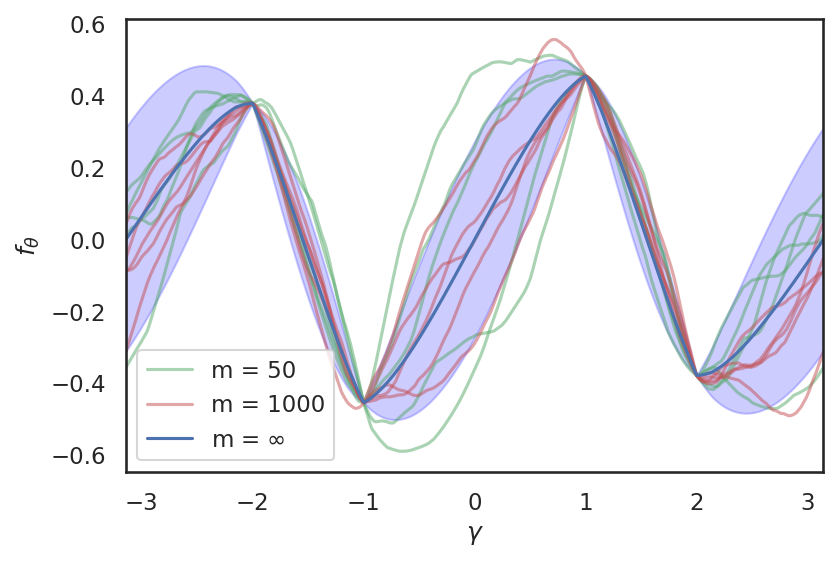

In [ ]:
plt.figure(dpi = 150)
for c, m in enumerate(ms):
  for i in range(reps):
    w, b, skey = generate_weights(2, skey, n_units = [m, m, m, 1])
    for t in range(1000):
      loss, grads = grad_step(X_train_s, Y_train_s, mse, w, b, final_activation = None)
      w = [wi - lr * dw for wi, dw in zip(w, grads[0])]
      b = [bi - lr * db for bi, db in zip(b, grads[1])]

    plt.plot(gammas_query, nn(X_query, w, b, final_activation=None), c = colors[c],
             label = f'm = {m}' if i == 0 else None, alpha = 0.5)

plt.plot(gammas_query, ntk_mean, c = colors[-1],
             label = 'm = $\infty$')
plt.fill_between(
    gammas_query,
    ntk_mean - 2 * ntk_std,
    ntk_mean +  2 * ntk_std,
    color='blue', alpha=0.2)

plt.xlabel('$\gamma$')
plt.ylabel(r'$f_{\theta}$')
plt.legend()
plt.xlim([-np.pi, +np.pi])
plt.show()

We see that the behavior of the networks (even with $m = 50$) is very similar to doing kernel regression with the NTK.

Now, we experiment with whether this linear behavior of the 3-hidden-layer NN could be caused by the fact that gradient descent dynamics are dominated by the final layer.

We consider three settings:
- Training all four layers of the network (i.e. as shown above) (**TrainAll**)
- Freezing the first three layers and training only the output layer (**TrainLast**)
- Freezing the final layer and training the first three layers (**FreezeLast**).

For each setting, we train 5 networks with different random initializations with 50 hidden units for 1000 epochs and plot them in function space.

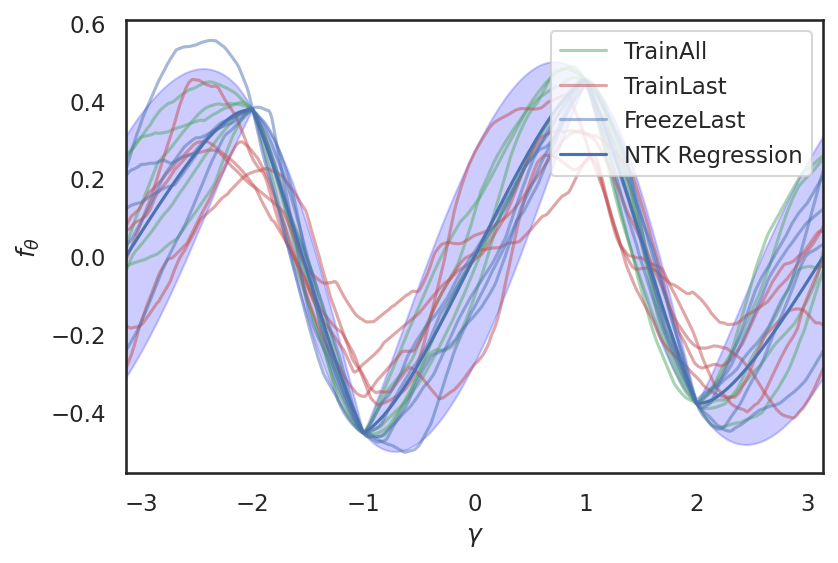

In [ ]:
reps = 5
modes = {
    'TrainAll': [True] * 4,
    'TrainLast': [False]*3 + [True],
    'FreezeLast': [True]*3 + [False]
}
m = 50

plt.figure(dpi = 150)
for c, mode in enumerate(modes):
  for i in range(reps):
    w, b, skey = generate_weights(2, skey, n_units = [m, m, m, 1])
    for t in range(1000):
        loss, grads = grad_step(X_train_s, Y_train_s, mse, w, b, final_activation = None)

        w = [wi - lr * dw if modes[mode][c] else wi for c, (wi, dw) in enumerate(zip(w, grads[0]))]
        b = [bi - lr * db if modes[mode][c] else bi for c, (bi, db) in enumerate(zip(b, grads[1]))]

    plt.plot(gammas_query, nn(X_query, w, b, final_activation=None), c = colors[c],
             label = mode if i == 0 else None, alpha = 0.5)

plt.plot(gammas_query, ntk_mean, c = colors[-1],
             label = 'NTK Regression')
plt.fill_between(
    gammas_query,
    ntk_mean - 2 * ntk_std,
    ntk_mean +  2 * ntk_std,
    color='blue', alpha=0.2)

plt.xlabel('$\gamma$')
plt.ylabel(r'$f_{\theta}$')
plt.legend()
plt.xlim([-np.pi, +np.pi])
plt.show()

We see that TrainAll and FreezeLast behave similarly, while TrainLast behaves quite differently, indicating that the NN with first three layers frozen does not explain the behavior of the network in general.

References used:
- https://colab.research.google.com/github/google/neural-tangents/blob/master/notebooks/neural_tangents_cookbook.ipynb#scrollTo=elaecFoO4Erp
- https://rajatvd.github.io/NTK/
- Jacot, Arthur, Franck Gabriel, and Clément Hongler. "Neural tangent kernel: convergence and generalization in neural networks." Proceedings of the 32nd International Conference on Neural Information Processing Systems. 2018. https://papers.nips.cc/paper/2018/file/5a4be1fa34e62bb8a6ec6b91d2462f5a-Paper.pdf